# Newyork City Airbnb

# Step 1: Import Data

I imported the libraries I needed (pandas, numpy, matplotlib/seaborn for visuals, and scikit-learn for preprocessing and modeling).

I also set up the scikit-learn tools I would use later (pipelines, imputers, encoding, and Ridge regression).

This notebook explores New York City Airbnb Open Data.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Step 2: Inspect the data

I loaded the NYC Airbnb dataset from `data/AB_NYC_2019.csv` and printed the basic details (shape, columns, and missing values). 

I also checked for duplicates so I could clean the dataset before modeling.

In [ ]:
# Display options for inspection
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

# Data path (file from archive / Kaggle NYC Airbnb)
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
file_path = data_dir / "AB_NYC_2019.csv"
if file_path.exists():
    df = pd.read_csv(file_path)
    print('Loaded existing dataset.')
    print('Dataset path:', file_path)
    print('Shape:', df.shape)
else:
    print('Place AB_NYC_2019.csv in the data/ folder (download from Kaggle link above)')
    df = None

Loaded existing dataset.
Dataset path: data\AB_NYC_2019.csv
Shape: (48895, 16)


In [ ]:
display(df.head()) #shows the first 5 rows of the dataframe
df.info() # Show Data types and number of non-null values
print('Rows, Columns:', df.shape) # checks for the number of rows and columns
print('Duplicate rows:', df.duplicated().sum()) # checks for duplicate rows
print('Total missing values:', int(df.isna().sum().sum())) # checks for null values

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

# Step 3: Cleaning Data

I cleaned the dataset before training. I removed duplicate rows, looked again at missing values, and dropped columns with too much missing data.

I then filtered out outliers for the price task (bad/placeholder prices and extreme minimum-night stays) so the model learns from listings that behave like normal short-term stays.

**To do:** Remove duplicate rows, review missing values, drop columns with too many missing values, remove obvious outliers, and prepare ordinal columns for encoding.

In [ ]:
# Build missing_summary and missing_pct; display a table of missing counts and percent.
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})
display(missing_table.head(15))

,missing_count,missing_pct
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03
neighbourhood_group,0,0.00
neighbourhood,0,0.00
id,0,0.00
host_id,0,0.00
longitude,0,0.00
latitude,0,0.00


In [ ]:
# remove Duplication
df = df.drop_duplicates().copy()

In [ ]:
#Handle Null Values In dataset
# Drop columns with more than 40% missing values
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
print('Columns dropped for high missingness:', cols_to_drop)
df = df.drop(columns=cols_to_drop)

Columns dropped for high missingness: []


**Outlier criteria (NYC Airbnb, simplified):** We drop **price** when `price == 0` (data error) or `price > 1000` (luxury), and **minimum nights** when `minimum_nights > 30` (long-term rentals). These matter most for price statistics and model performance.

In [ ]:
# Remove outliers using simplified criteria (price and minimum_nights only)
price_outliers = (df['price'] == 0) | (df['price'] > 1000)
min_night_outliers = df['minimum_nights'] > 30
outlier_mask = price_outliers | min_night_outliers
print('Rows removed as outliers:', outlier_mask.sum())
df = df[~outlier_mask].copy()

Rows removed as outliers: 971


**Feature engineering.** We add two business-relevant features: **min_booking_cost** is price × minimum_nights (e.g. 2-night minimum at $100 per night gives $200). **host_type** is "commercial" if calculated_host_listings_count > 5, else "individual", to separate multi-listing hosts from individuals.

In [ ]:
# Feature engineering: min_booking_cost and host_type
df["min_booking_cost"] = df["price"] * df["minimum_nights"]
df["host_type"] = df["calculated_host_listings_count"].apply(lambda x: "commercial" if x > 5 else "individual")
print("New columns:", ["min_booking_cost", "host_type"])
display(df[["price", "minimum_nights", "min_booking_cost", "calculated_host_listings_count", "host_type"]].head(8))

New columns: ['min_booking_cost', 'host_type']


,price,minimum_nights,min_booking_cost,calculated_host_listings_count,host_type
0,149,1,149,6,commercial
1,225,1,225,2,individual
2,150,3,450,1,individual
3,89,1,89,1,individual
4,80,10,800,1,individual
5,200,3,600,1,individual
7,79,2,158,1,individual
8,79,2,158,1,individual


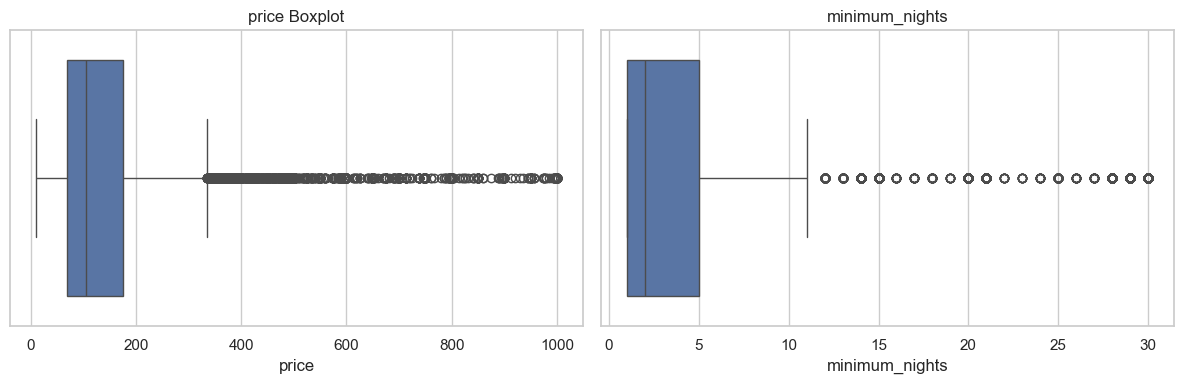

In [ ]:
# Plot boxplots for SalePrice and Gr Liv Area 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['price'], ax=axes[0])
axes[0].set_title('price Boxplot')
sns.boxplot(x=df['minimum_nights'], ax=axes[1])
axes[1].set_title('minimum_nights')
plt.tight_layout()
plt.show()

# Step 4: Encoding Ordinal Categorical Variables

I prepared my categorical variables for the model. I treated `room_type` as an ordinal feature using a fixed order (Shared room < Private room < Entire home/apt).

For the remaining categorical variables, I planned to use one-hot encoding inside the preprocessing pipeline so the model can handle categories without assuming any ordering.

We encode ordinal quality columns with an explicit numeric order; the rest are nominal and get one-hot encoded in the model pipeline.

**Ordinal and categorical variables (NYC Airbnb).** Ordinal (natural order, encoded with a numeric map): `room_type` as Shared room (1), Private room (2), Entire home/apt (3). Nominal (one-hot encoded later): `neighbourhood_group`, `neighbourhood`, and `host_type` (individual vs commercial).

In [ ]:
# Ordinal encoding for room_type (order: shared < private < entire)
room_type_ordinal_map = {
    'Shared room': 1,
    'Private room': 2,
    'Entire home/apt': 3
}
if 'room_type' in df.columns:
    df['room_type'] = df['room_type'].map(room_type_ordinal_map)

# Categorical columns (for one-hot encoding later in modeling)
categorical_cols = ['neighbourhood_group', 'neighbourhood', 'host_type']

print('Ordinal column encoded: room_type')
print('Categorical columns (one-hot later):', categorical_cols)
display(df[['room_type', 'neighbourhood_group', 'neighbourhood', 'host_type']].head())

Ordinal column encoded: room_type
Categorical columns (one-hot later): ['neighbourhood_group', 'neighbourhood', 'host_type']


,room_type,neighbourhood_group,neighbourhood,host_type
0,2,Brooklyn,Kensington,commercial
1,3,Manhattan,Midtown,individual
2,2,Manhattan,Harlem,individual
3,3,Brooklyn,Clinton Hill,individual
4,3,Manhattan,East Harlem,individual


# Step 5: Exploratory Data Analysis (EDA)

I explored the dataset to understand what’s going on before training. I checked correlations with the target (`price`) and created summary plots (distributions and relationships) for key variables.

This helped me see which features look most connected to price and what might need extra attention in preprocessing.

In [ ]:
df.info() # Show Data types and number of non-null values
print('Rows, Columns:', df.shape) # checks for the number of rows and columns
print('Duplicate rows:', df.duplicated().sum()) # checks for duplicate rows
print('Total missing values:', int(df.isna().sum().sum())) # checks for null values

<class 'pandas.DataFrame'>
Index: 47924 entries, 0 to 48894
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              47924 non-null  int64  
 1   name                            47909 non-null  str    
 2   host_id                         47924 non-null  int64  
 3   host_name                       47903 non-null  str    
 4   neighbourhood_group             47924 non-null  str    
 5   neighbourhood                   47924 non-null  str    
 6   latitude                        47924 non-null  float64
 7   longitude                       47924 non-null  float64
 8   room_type                       47924 non-null  int64  
 9   price                           47924 non-null  int64  
 10  minimum_nights                  47924 non-null  int64  
 11  number_of_reviews               47924 non-null  int64  
 12  last_review                     38294 non-null  

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
corr_to_target = numeric_df.corr(numeric_only=True)['price'].sort_values(ascending=False)
display(corr_to_target.head(15).to_frame('Correlation with price'))

,Correlation with price
price,1.000000
room_type,0.462708
min_booking_cost,0.416608
calculated_host_listings_count,0.129981
availability_365,0.117174
latitude,0.062890
minimum_nights,0.044688
host_id,0.031782
id,0.020868
reviews_per_month,-0.031333


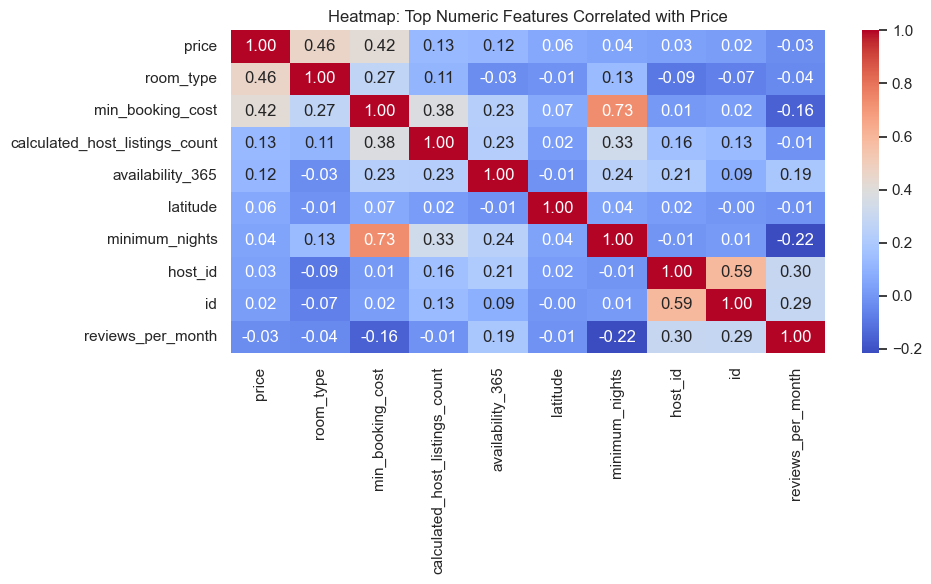

In [ ]:
# Heatmap of top 10 features correlated with price
top_corr_cols = corr_to_target.head(10).index.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(df[top_corr_cols].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap: Top Numeric Features Correlated with Price')
plt.tight_layout()
plt.show()

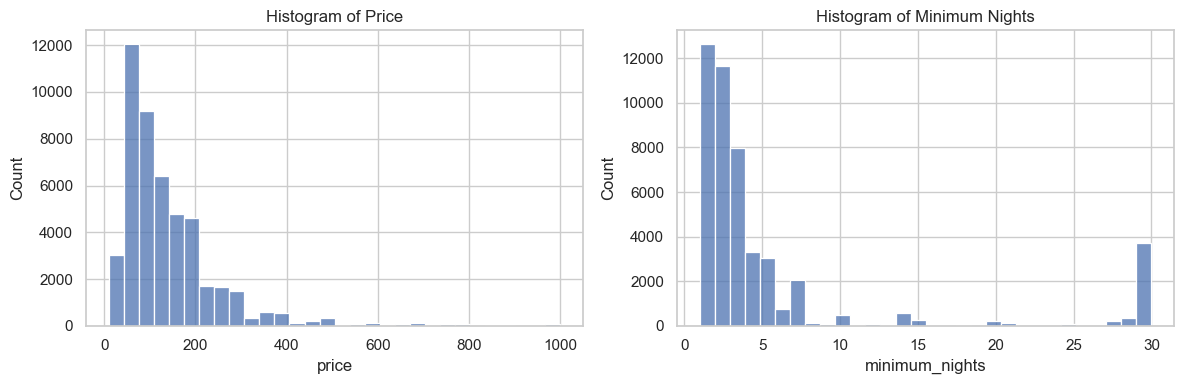

In [ ]:
# Histograms of key variables (price and minimum_nights)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], bins=30, ax=axes[0])
axes[0].set_title('Histogram of Price')
sns.histplot(df['minimum_nights'], bins=30, ax=axes[1])
axes[1].set_title('Histogram of Minimum Nights')
plt.tight_layout()
plt.show()

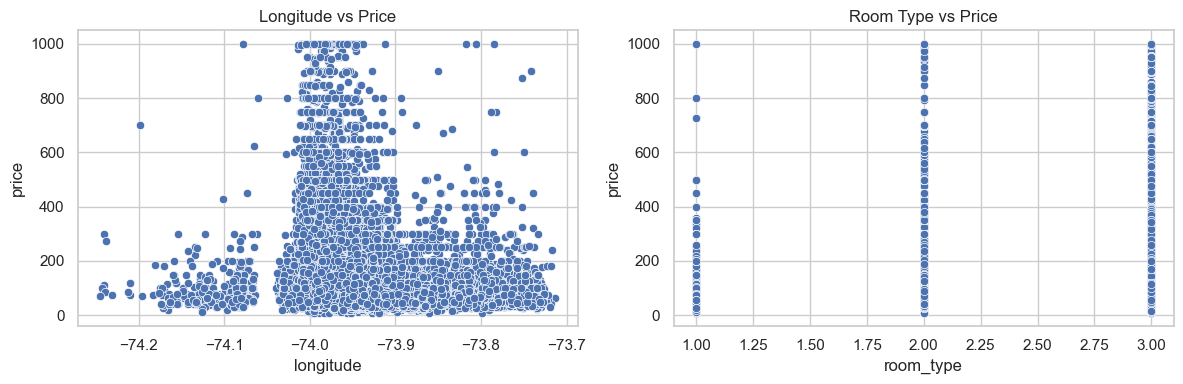

In [ ]:
# Scatter plots: key features vs price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x='longitude', y='price', ax=axes[0])
axes[0].set_title('Longitude vs Price')
sns.scatterplot(data=df, x='room_type', y='price', ax=axes[1])
axes[1].set_title('Room Type vs Price')
plt.tight_layout()
plt.show()

# Step 6: Feature Engineering

I added a couple of features that make the prediction problem more meaningful. I computed `min_booking_cost` (price times minimum nights) and created `host_type` to distinguish multi-listing hosts from individual hosts.

After that, I printed the new columns so I could confirm the feature engineering worked as expected.

In [ ]:
# Check multicollinearity among features correlated with price
# (Use 0.2 threshold since no NYC Airbnb feature has correlation >= 0.6 with price)
strong_features = corr_to_target[abs(corr_to_target) >= 0.2].index.tolist()
strong_features = [c for c in strong_features if c != 'price']
if strong_features:
    strong_corr = df[strong_features].corr(numeric_only=True).abs()
    upper = strong_corr.where(np.triu(np.ones(strong_corr.shape), k=1).astype(bool))
    high_pairs = (upper.stack()
                  .reset_index()
                  .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Abs_Correlation'})
                  .query('Abs_Correlation >= 0.8')
                  .sort_values('Abs_Correlation', ascending=False))
    display(high_pairs.head(10))
else:
    print('No strong features found at the chosen threshold.')

,Feature_1,Feature_2,Abs_Correlation


# Step 7: Model and 10-fold cross-validation

**K = 10** folds for cross-validation gives more stable performance estimates.

In [ ]:
# 10-fold cross-validation (k=10)
k = 10
cv = KFold(n_splits=k, shuffle=True, random_state=42)

# Prepare X and y (use numeric + categorical; exclude ids and target)
drop_cols = ['price', 'id', 'name', 'host_id', 'host_name', 'last_review']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['price']

# Numeric vs categorical
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in categorical_cols if c in X.columns]

# Preprocessor: impute + scale numeric; one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ],
    remainder='drop'
)
model = Pipeline([('prep', preprocessor), ('ridge', Ridge())])

# Run 10-fold CV
scores = cross_validate(model, X, y, cv=cv, scoring=('neg_mean_absolute_error', 'r2'), return_train_score=True)
print(f'KFold n_splits = {k}')
print('MAE (mean ± std):', -scores['test_neg_mean_absolute_error'].mean().round(2), '±', scores['test_neg_mean_absolute_error'].std().round(2))
print('R²  (mean ± std):', scores['test_r2'].mean().round(4), '±', scores['test_r2'].std().round(4))

KFold n_splits = 10
MAE (mean ± std): 49.67 ± 1.12
R²  (mean ± std): 0.5025 ± 0.0152


# Step 8: Separate Features and Target

I separated the inputs and the label: `X` contains all features, and `y` is the target (`price`).

I printed the shapes to confirm the dataset sizes matched what I expected after cleaning.

In [ ]:
X = df.drop(columns=['price'])
y = df['price']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (47924, 17)
y shape: (47924,)


# Step 9: Train-test Split

I split the dataset into a training part and a test part using `train_test_split` (with `random_state=42`).

I printed the resulting shapes so I could verify the split sizes before training and evaluation.

In [ ]:
# train_test_split(X, y, test_size=0.2, random_state=42); print shapes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Test data
print('X_test :', X_test.shape)
print('y_test :', y_test.shape)

#Training data
print('y_train:', y_train.shape)
print('X_train:', X_train.shape)

X_test : (9585, 17)
y_test : (9585,)
y_train: (38339,)
X_train: (38339, 17)


# Step 10: Build Preprocessing + Model Pipeline

I built a single pipeline that performs preprocessing and modeling together, so the transformations happen consistently.

I set up: median imputation + scaling for numeric columns, most-frequent imputation + one-hot encoding for categorical columns, and then I trained a **Ridge Regression** model.


In [ ]:
#Taking Training date, Split into Numeric and Categorical
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

#For Number Data - Fill in Null Value with Median And Then Normalise
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#For Categorical Data - Fill in Null Value with Mode And Then One-Hot_encode NORMINAL DATA
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Merge the transformed data back into a whole training data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# Step 11: K-fold Cross Validation on The Training Data

I evaluated the model using K-fold cross-validation (k = 10). This gives me a more reliable estimate of performance than a single train-test split.

I reported MAE and R2 across folds to see how stable the model is.

In [ ]:
# KFold(5, shuffle=True, random_state=42); cross_validate with mae, rmse, r2; display CV results table and means
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },
    n_jobs=-1
)

cv_table = pd.DataFrame({
    'Fold': range(1, 11),
    'MAE': -cv_results['test_mae'],
    'RMSE': -cv_results['test_rmse'],
    'R2': cv_results['test_r2']
})

display(cv_table)
print('Mean CV MAE :', round(cv_table['MAE'].mean(), 2))
print('Mean CV RMSE:', round(cv_table['RMSE'].mean(), 2))
print('Mean CV R2  :', round(cv_table['R2'].mean(), 4))


,Fold,MAE,RMSE,R2
0,1,49.762296,82.395997,0.505697
1,2,46.804753,75.323096,0.531041
2,3,47.246662,76.749531,0.549545
3,4,48.793668,79.697579,0.552510
4,5,48.701120,78.858067,0.553055
5,6,47.786314,78.754696,0.539740
6,7,48.805671,82.181032,0.511796
7,8,48.718835,82.020400,0.529875
8,9,48.334950,78.162520,0.548292
9,10,50.871248,82.908947,0.534650


Mean CV MAE : 48.58
Mean CV RMSE: 79.71
Mean CV R2  : 0.5356
